In [68]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from sklearn.ensemble import RandomForestClassifier

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [69]:
# Load datasets
train = pd.read_csv("public_trip_data.csv")
test = pd.read_csv("private_trip_data.csv")

In [70]:
train.head()

,TripID,DepartureLocationCountry,DepartureLocationCity,ArrivalLocationCountry,ArrivalLocationCity,ShippingType,ShippingTypeDescription,Purpose,OutOfPolicy,EntitiyCode,EmployeeNumber,BusinessUnit,HotelNights,NetCosts,Departure_CO2e,Return_CO2e,Hotel_CO2e,Spend_CO2e,TotalCO2e,HighCarbon
0,1,CN,Beijing,IN,New Delhi,12,Business Class Flight,Customer Visit,No,9000,M1000-M5008,Services,1,900,1565.121857,1565.121857,58.9,1472.279257,3189.143714,0
1,3,US,New York,MX,Mexico City,11,First Class Flight,Customer Visit,Yes,6000,M1000-M5030,Sales,2,3600,743.295848,743.295848,38.6,2921.504761,1525.191696,0
2,6,BR,SÃ£o Paulo,ZA,Johannesburg,10,Economy Flight,Conference/Exhibition,No,9000,M1000-M5069,Services,1,450,1053.713528,1053.713528,51.4,743.646219,2158.827056,0
3,7,DE,Berlin,FR,Paris,12,Business Class Flight,Customer Visit,No,10000,M1000-M5095,Executive Management,1,3450,196.262703,196.262703,6.7,3343.160260,399.225407,0
4,8,BR,SÃ£o Paulo,ZA,Johannesburg,10,Economy Flight,Internal Business Trip,No,7000,M1000-M5097,Marketing,2,1500,1053.713528,1053.713528,102.8,2478.820729,2210.227056,0


In [71]:
print("Training Data Shape:", train.shape)
print("Testing Data Shape:", test.shape)


Training Data Shape: (65289, 20)
Testing Data Shape: (21764, 13)


In [72]:
train.columns

Index(['TripID', 'DepartureLocationCountry', 'DepartureLocationCity',
       'ArrivalLocationCountry', 'ArrivalLocationCity', 'ShippingType',
       'ShippingTypeDescription', 'Purpose', 'OutOfPolicy', 'EntitiyCode',
       'EmployeeNumber', 'BusinessUnit', 'HotelNights', 'NetCosts',
       'Departure_CO2e', 'Return_CO2e', 'Hotel_CO2e', 'Spend_CO2e',
       'TotalCO2e', 'HighCarbon'],
      dtype='object')

In [73]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65289 entries, 0 to 65288
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   TripID                    65289 non-null  int64  
 1   DepartureLocationCountry  65289 non-null  object 
 2   DepartureLocationCity     65289 non-null  object 
 3   ArrivalLocationCountry    65289 non-null  object 
 4   ArrivalLocationCity       65289 non-null  object 
 5   ShippingType              65289 non-null  int64  
 6   ShippingTypeDescription   65289 non-null  object 
 7   Purpose                   65289 non-null  object 
 8   OutOfPolicy               65289 non-null  object 
 9   EntitiyCode               65289 non-null  int64  
 10  EmployeeNumber            65289 non-null  object 
 11  BusinessUnit              65289 non-null  object 
 12  HotelNights               65289 non-null  int64  
 13  NetCosts                  65289 non-null  int64  
 14  Depart

In [74]:
train["HighCarbon"].value_counts()

,count
HighCarbon,
0,48963
1,16326


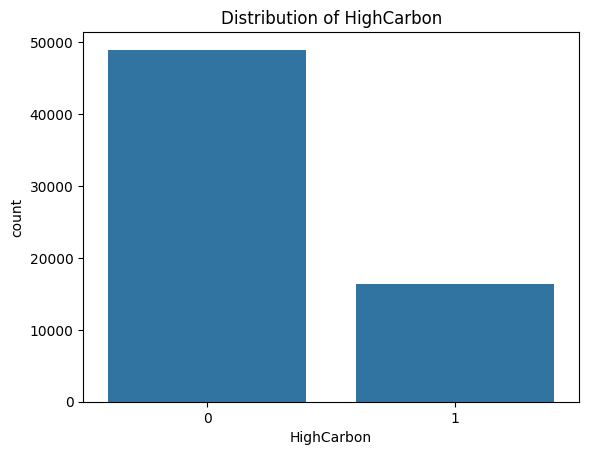

In [75]:
sns.countplot(x="HighCarbon", data=train)
plt.title("Distribution of HighCarbon")
plt.show()

In [76]:
test.head()

,TripID,DepartureLocationCountry,DepartureLocationCity,ArrivalLocationCountry,ArrivalLocationCity,ShippingType,ShippingTypeDescription,Purpose,OutOfPolicy,EntitiyCode,BusinessUnit,HotelNights,NetCosts
0,2,BR,SÃ£o Paulo,ZA,Johannesburg,12,Business Class Flight,Customer Visit,Yes,8000,Sales,6,2400
1,4,CN,Beijing,GB,London,10,Economy Flight,Internal Business Trip,No,8000,Customer Support,3,3150
2,5,AU,Sydney,US,Los Angeles,10,Economy Flight,Conference/Exhibition,No,8000,Marketing,6,3000
3,14,BR,SÃ£o Paulo,US,Miami,10,Economy Flight,Conference/Exhibition,No,8000,Executive Management,2,1350
4,15,DE,Berlin,ES,Madrid,12,Business Class Flight,Conference/Exhibition,Yes,8000,Marketing,2,2850


In [77]:
test.columns

Index(['TripID', 'DepartureLocationCountry', 'DepartureLocationCity',
       'ArrivalLocationCountry', 'ArrivalLocationCity', 'ShippingType',
       'ShippingTypeDescription', 'Purpose', 'OutOfPolicy', 'EntitiyCode',
       'BusinessUnit', 'HotelNights', 'NetCosts'],
      dtype='object')

In [78]:
# Select only common features
features = [
    "DepartureLocationCountry",
    "DepartureLocationCity",
    "ArrivalLocationCountry",
    "ArrivalLocationCity",
    "ShippingType",
    "ShippingTypeDescription",
    "Purpose",
    "OutOfPolicy",
    "EntitiyCode",
    "BusinessUnit",
    "HotelNights",
    "NetCosts"
]

# Features
X = train[features]

# Target
y = train["HighCarbon"]

# Test data
X_test = test[features]

In [79]:
from sklearn.preprocessing import LabelEncoder

# Encode categorical columns
label_encoders = {}

categorical_cols = X.select_dtypes(include=['object']).columns

for col in categorical_cols:
    le = LabelEncoder()

    # Fit on combined train + test data
    combined = pd.concat([X[col], X_test[col]], axis=0).astype(str)

    le.fit(combined)

    X[col] = le.transform(X[col].astype(str))
    X_test[col] = le.transform(X_test[col].astype(str))

    label_encoders[col] = le

In [80]:
X.head()

,DepartureLocationCountry,DepartureLocationCity,ArrivalLocationCountry,ArrivalLocationCity,ShippingType,ShippingTypeDescription,Purpose,OutOfPolicy,EntitiyCode,BusinessUnit,HotelNights,NetCosts
0,2,0,8,17,12,2,1,0,9000,11,1,900
1,7,7,11,14,11,5,1,1,6000,10,2,3600
2,1,9,19,8,10,3,0,0,9000,11,1,450
3,3,1,6,19,12,2,1,0,10000,3,1,3450
4,1,9,19,8,10,3,3,0,7000,6,2,1500


In [81]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [82]:
print(X_train.shape)
print(X_valid.shape)

(52231, 12)
(13058, 12)


In [83]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [84]:
pred = model.predict(X_valid)

In [85]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_valid, pred)

print("Accuracy:", accuracy)

Accuracy: 0.9917292081482616


In [86]:
from sklearn.metrics import roc_auc_score

pred_prob = model.predict_proba(X_valid)[:, 1]

roc = roc_auc_score(y_valid, pred_prob)

print("ROC AUC:", roc)

ROC AUC: 0.9979587726270711


In [87]:
test_prob = model.predict_proba(X_test)[:, 1]

In [88]:
submission = pd.read_csv("sample_submission.csv")

submission.head()

,TripID,HighCarbon
0,2,0.0
1,4,0.0
2,5,0.0
3,14,0.0
4,15,0.0


In [89]:
submission["HighCarbon"] = test_prob


In [90]:
submission.to_csv("submission.csv", index=False)

print("Submission file created successfully!")

Submission file created successfully!


In [91]:
submission.head()

,TripID,HighCarbon
0,2,1.0000
1,4,0.0000
2,5,0.9675
3,14,0.0000
4,15,0.0000


In [92]:
# Create a DataFrame of feature importances
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

# Sort by importance
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
2,ArrivalLocationCountry,0.240231
3,ArrivalLocationCity,0.210938
0,DepartureLocationCountry,0.135272
4,ShippingType,0.128378
5,ShippingTypeDescription,0.122260
1,DepartureLocationCity,0.081266
10,HotelNights,0.033270
7,OutOfPolicy,0.015701
11,NetCosts,0.014175
9,BusinessUnit,0.008282


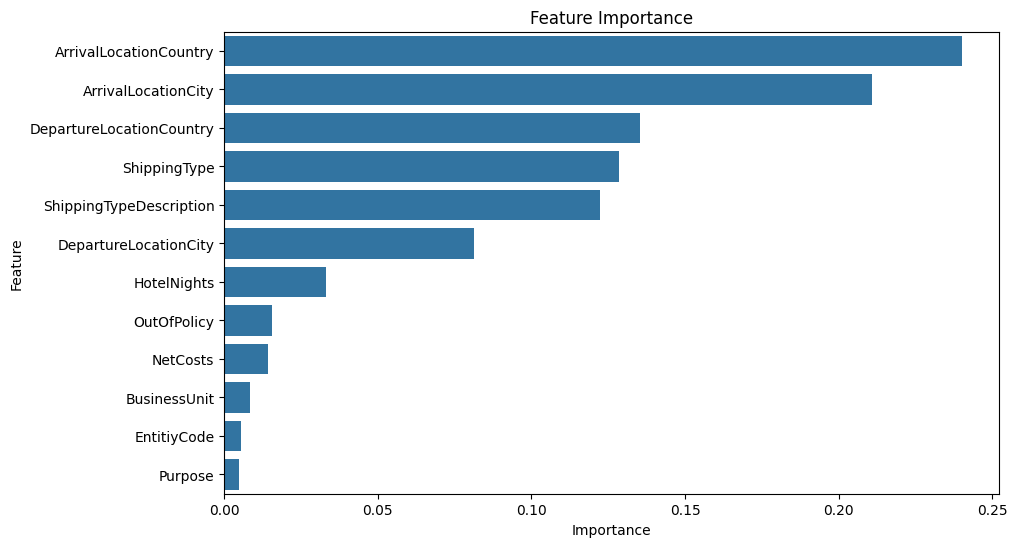

In [93]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")
plt.show()

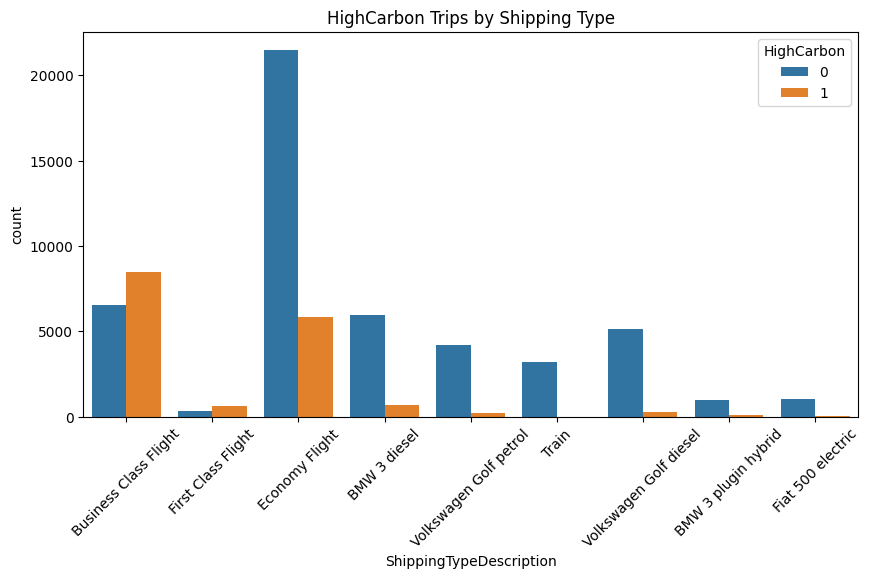

In [94]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=train,
    x="ShippingTypeDescription",
    hue="HighCarbon"
)

plt.xticks(rotation=45)
plt.title("HighCarbon Trips by Shipping Type")
plt.show()

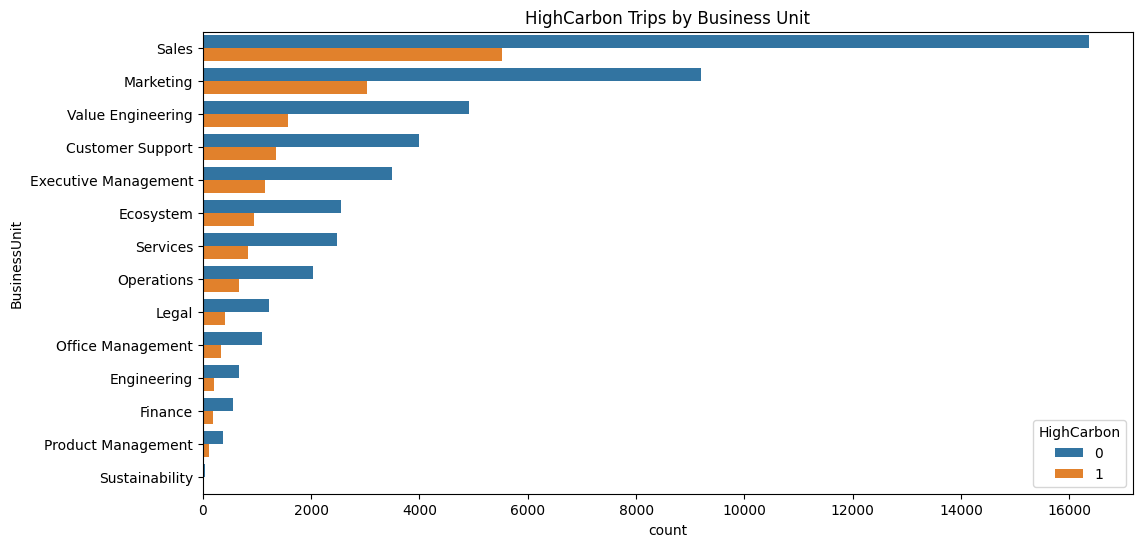

In [95]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=train,
    y="BusinessUnit",
    hue="HighCarbon",
    order=train["BusinessUnit"].value_counts().index
)

plt.title("HighCarbon Trips by Business Unit")
plt.show()

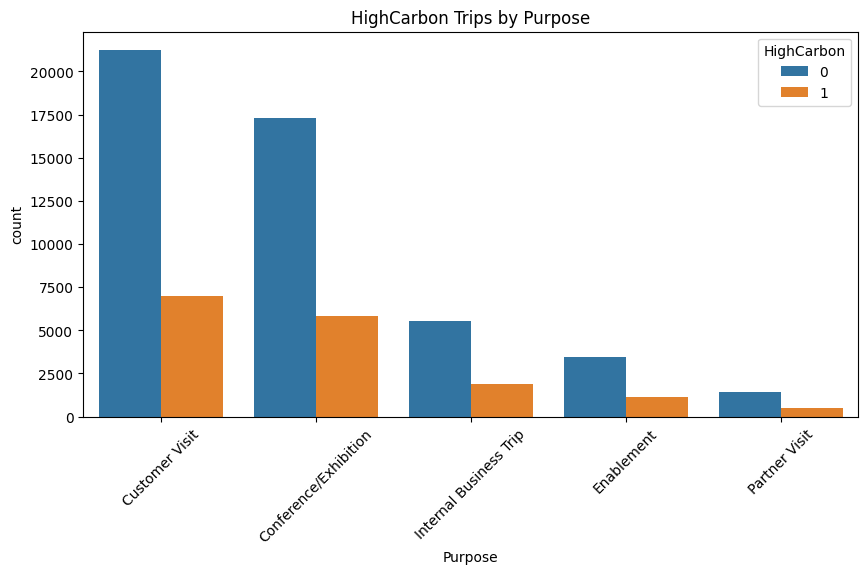

In [96]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=train,
    x="Purpose",
    hue="HighCarbon"
)

plt.xticks(rotation=45)
plt.title("HighCarbon Trips by Purpose")
plt.show()

In [97]:
import pandas as pd

event_log = pd.read_csv("public_trip_event_log.csv")

event_log.head()

,TripID,StepOrder,EventName,EventTimestamp
0,1,1,Book Mode of Transportation,03/21/2024 23:36:20
1,1,2,Book Lodging,03/22/2024 09:16:16
2,1,3,Submit Travel Request,03/22/2024 12:15:19
3,1,4,Travel Request Approved,03/23/2024 08:12:58
4,1,5,Receive Confirmation,03/23/2024 23:42:47


In [98]:
event_log.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 671547 entries, 0 to 671546
Data columns (total 4 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   TripID          671547 non-null  int64 
 1   StepOrder       671547 non-null  int64 
 2   EventName       671547 non-null  object
 3   EventTimestamp  671547 non-null  object
dtypes: int64(2), object(2)
memory usage: 20.5+ MB


In [99]:
event_log.shape

(671547, 4)

In [100]:
event_log.columns

Index(['TripID', 'StepOrder', 'EventName', 'EventTimestamp'], dtype='object')

In [101]:
event_log.head()
event_log.info()
event_log.shape
event_log.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 671547 entries, 0 to 671546
Data columns (total 4 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   TripID          671547 non-null  int64 
 1   StepOrder       671547 non-null  int64 
 2   EventName       671547 non-null  object
 3   EventTimestamp  671547 non-null  object
dtypes: int64(2), object(2)
memory usage: 20.5+ MB


Index(['TripID', 'StepOrder', 'EventName', 'EventTimestamp'], dtype='object')

In [102]:
event_log["TripID"].nunique()

65289

In [103]:
len(event_log)

671547

In [104]:
events_per_trip = event_log.groupby("TripID").size()

events_per_trip.describe()

,0
count,65289.000000
mean,10.285760
std,1.311022
min,2.000000
25%,10.000000
50%,10.000000
75%,11.000000
max,14.000000


In [105]:
event_log["EventName"].value_counts()

,count
EventName,
Book Mode of Transportation,68134
Submit Travel Request,65289
Receive Confirmation,62982
Travel Request Approved,62982
Submit Expense Request,62903
Expense Reimbursement,62847
Expense Request Approved,62847
Book Lodging,59815
Take Departure Flight,41735


In [106]:
event_log["TripID"].nunique()

len(event_log)

events_per_trip = event_log.groupby("TripID").size()
events_per_trip.describe()

event_log["EventName"].value_counts()

,count
EventName,
Book Mode of Transportation,68134
Submit Travel Request,65289
Receive Confirmation,62982
Travel Request Approved,62982
Submit Expense Request,62903
Expense Reimbursement,62847
Expense Request Approved,62847
Book Lodging,59815
Take Departure Flight,41735


In [107]:
# Build process variants
process_variants = event_log.groupby("TripID")["EventName"].apply(
    lambda x: " → ".join(x)
)

# Top 10 most common process variants
process_variants.value_counts().head(10)

,count
EventName,
Book Mode of Transportation → Book Lodging → Submit Travel Request → Travel Request Approved → Receive Confirmation → Take Departure Flight → Take Return Flight → Submit Expense Request → Expense Request Approved → Expense Reimbursement,23017
Book Mode of Transportation → Book Lodging → Submit Travel Request → Travel Request Approved → Receive Confirmation → Pickup Rental → Return Rental → Submit Expense Request → Expense Request Approved → Expense Reimbursement,9945
Manager Preapproved → Trip Extension → Book Mode of Transportation → Book Lodging → Submit Travel Request,2060
Book Mode of Transportation → Book Lodging → Submit Travel Request → Travel Request Approved → Receive Confirmation → Take Departure Train → Take Return Train → Submit Expense Request → Expense Request Approved → Expense Reimbursement,1663
Manager Preapproved → Trip Extension → Book Mode of Transportation → Book Lodging → Submit Travel Request → Travel Request Approved → Receive Confirmation → Take Departure Flight → Take Return Flight → Submit Expense Request → Expense Request Approved → Expense Reimbursement,1327
Manager Preapproved → Trip Extension → Book Mode of Transportation → Submit Travel Request → Travel Request Approved → Receive Confirmation → Take Departure Flight → Take Return Flight → Submit Expense Request → Expense Request Approved → Expense Reimbursement,1277
Book Mode of Transportation → Submit Travel Request → Travel Request Approved → Receive Confirmation → Take Departure Flight → Take Return Flight → Submit Expense Request → Expense Request Approved → Expense Reimbursement,1268
Manager Preapproved → Book Mode of Transportation → Book Lodging → Submit Travel Request → Travel Request Approved → Receive Confirmation → Take Departure Flight → Take Return Flight → Submit Expense Request → Expense Request Approved → Expense Reimbursement,1266
Manager Preapproved → Itinerary Edit → Book Mode of Transportation → Book Lodging → Submit Travel Request → Travel Request Approved → Receive Confirmation → Take Departure Flight → Take Return Flight → Submit Expense Request → Expense Request Approved → Expense Reimbursement,1249


In [108]:
# Convert timestamp to datetime
event_log["EventTimestamp"] = pd.to_datetime(event_log["EventTimestamp"])

# Duration of each trip
trip_duration = event_log.groupby("TripID")["EventTimestamp"].agg(
    ["min", "max"]
)

trip_duration["Duration_Hours"] = (
    trip_duration["max"] - trip_duration["min"]
).dt.total_seconds() / 3600

trip_duration.describe()

,min,max,Duration_Hours
count,65289,65289,65289.000000
mean,2024-06-22 07:40:07.175864320,2024-07-14 14:17:55.169339392,534.629998
min,2023-12-01 18:10:45,2024-01-02 21:04:02,0.000556
25%,2024-03-24 01:07:40,2024-04-16 00:23:35,359.785556
50%,2024-06-22 05:17:19,2024-07-15 12:17:43,576.726111
75%,2024-09-21 09:43:05,2024-10-14 08:43:14,717.449167
max,2025-06-04 14:49:00,2025-06-23 06:10:33,968.538889
std,NaN,NaN,226.727378


In [109]:
# Convert EventTimestamp into datetime format
event_log["EventTimestamp"] = pd.to_datetime(event_log["EventTimestamp"])

# Find first and last event of every trip
trip_duration = event_log.groupby("TripID")["EventTimestamp"].agg(["min", "max"])

# Calculate trip duration in hours
trip_duration["Duration_Hours"] = (
    trip_duration["max"] - trip_duration["min"]
).dt.total_seconds() / 3600

# Summary statistics
trip_duration["Duration_Hours"].describe()

,Duration_Hours
count,65289.000000
mean,534.629998
std,226.727378
min,0.000556
25%,359.785556
50%,576.726111
75%,717.449167
max,968.538889


In [110]:
import matplotlib.pyplot as plt

In [111]:
import matplotlib.pyplot as plt
import seaborn as sns

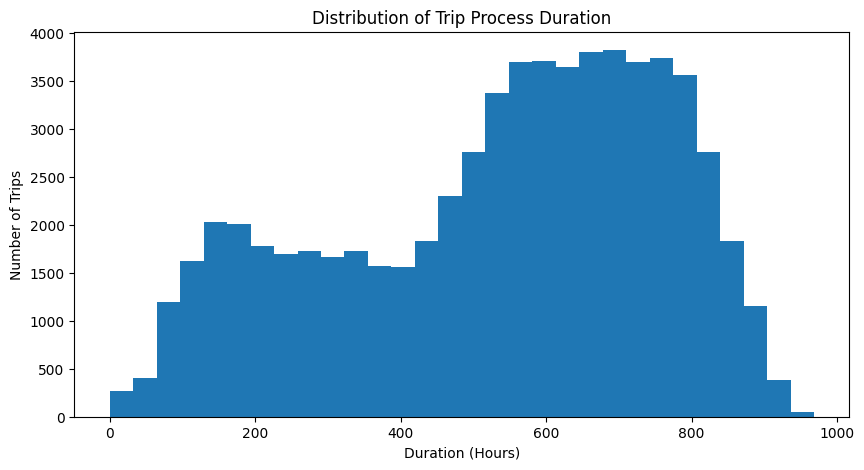

In [112]:
plt.figure(figsize=(10,5))

plt.hist(trip_duration["Duration_Hours"], bins=30)

plt.title("Distribution of Trip Process Duration")
plt.xlabel("Duration (Hours)")
plt.ylabel("Number of Trips")

plt.show()

In [113]:
event_attr = pd.read_csv("public_trip_event_attributes.csv")

event_attr.head()

,TripID,EmployeeNumber,TravelRequestID,ExpenseRequestID,ExpenseDenialReason,ExpenseReimbursementReason,ExpenseReimbursementAmount,ReasonForTransportCancellation,NewTransportSelection,ReasonForNewTransport,NewHotelSelection,ReasonForNewHotel,NewModeOfTransportation,TransportationPriceDifference,ReasonForTransportationChange,ReasonForDelay,ExtensionLength,DaysPreapproved,ProcessCode
0,1,M1000-M5008,TR000001,EXP000001,NaN,Policy exception approved,267.89,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,V1
1,3,M1000-M5030,TR000003,EXP000003,NaN,Partial reimbursement,526.90,Personal emergency,Rebooked flight,Better schedule,NaN,NaN,Updated First Class Flight,140.62,Time constraints,NaN,NaN,2,V1
2,6,M1000-M5069,TR000006,EXP000006,NaN,Policy exception approved,487.03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Weather delay,NaN,1,V1
3,7,M1000-M5095,TR000007,EXP000007,NaN,Policy exception approved,511.29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,V1
4,8,M1000-M5097,TR000008,EXP000008,NaN,Standard travel reimbursement,452.41,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Mechanical issue,NaN,2,V20


In [114]:
event_attr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65289 entries, 0 to 65288
Data columns (total 19 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   TripID                          65289 non-null  int64  
 1   EmployeeNumber                  65289 non-null  object 
 2   TravelRequestID                 65289 non-null  object 
 3   ExpenseRequestID                64930 non-null  object 
 4   ExpenseDenialReason             10773 non-null  object 
 5   ExpenseReimbursementReason      64521 non-null  object 
 6   ExpenseReimbursementAmount      64930 non-null  float64
 7   ReasonForTransportCancellation  3871 non-null   object 
 8   NewTransportSelection           8986 non-null   object 
 9   ReasonForNewTransport           8986 non-null   object 
 10  NewHotelSelection               8828 non-null   object 
 11  ReasonForNewHotel               8828 non-null   object 
 12  NewModeOfTransportation         

In [115]:
event_attr.shape

(65289, 19)

In [116]:
event_attr.columns

Index(['TripID', 'EmployeeNumber', 'TravelRequestID', 'ExpenseRequestID',
       'ExpenseDenialReason', 'ExpenseReimbursementReason',
       'ExpenseReimbursementAmount', 'ReasonForTransportCancellation',
       'NewTransportSelection', 'ReasonForNewTransport', 'NewHotelSelection',
       'ReasonForNewHotel', 'NewModeOfTransportation',
       'TransportationPriceDifference', 'ReasonForTransportationChange',
       'ReasonForDelay', 'ExtensionLength', 'DaysPreapproved', 'ProcessCode'],
      dtype='object')

In [117]:
event_attr.head()

,TripID,EmployeeNumber,TravelRequestID,ExpenseRequestID,ExpenseDenialReason,ExpenseReimbursementReason,ExpenseReimbursementAmount,ReasonForTransportCancellation,NewTransportSelection,ReasonForNewTransport,NewHotelSelection,ReasonForNewHotel,NewModeOfTransportation,TransportationPriceDifference,ReasonForTransportationChange,ReasonForDelay,ExtensionLength,DaysPreapproved,ProcessCode
0,1,M1000-M5008,TR000001,EXP000001,NaN,Policy exception approved,267.89,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,V1
1,3,M1000-M5030,TR000003,EXP000003,NaN,Partial reimbursement,526.90,Personal emergency,Rebooked flight,Better schedule,NaN,NaN,Updated First Class Flight,140.62,Time constraints,NaN,NaN,2,V1
2,6,M1000-M5069,TR000006,EXP000006,NaN,Policy exception approved,487.03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Weather delay,NaN,1,V1
3,7,M1000-M5095,TR000007,EXP000007,NaN,Policy exception approved,511.29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,V1
4,8,M1000-M5097,TR000008,EXP000008,NaN,Standard travel reimbursement,452.41,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Mechanical issue,NaN,2,V20


In [118]:
missing = event_attr.isnull().sum().sort_values(ascending=False)

missing

,0
ReasonForTransportCancellation,61418
ExtensionLength,59300
ReasonForDelay,58453
TransportationPriceDifference,57767
ReasonForTransportationChange,57767
NewModeOfTransportation,57767
ReasonForNewHotel,56461
NewHotelSelection,56461
NewTransportSelection,56303
ReasonForNewTransport,56303


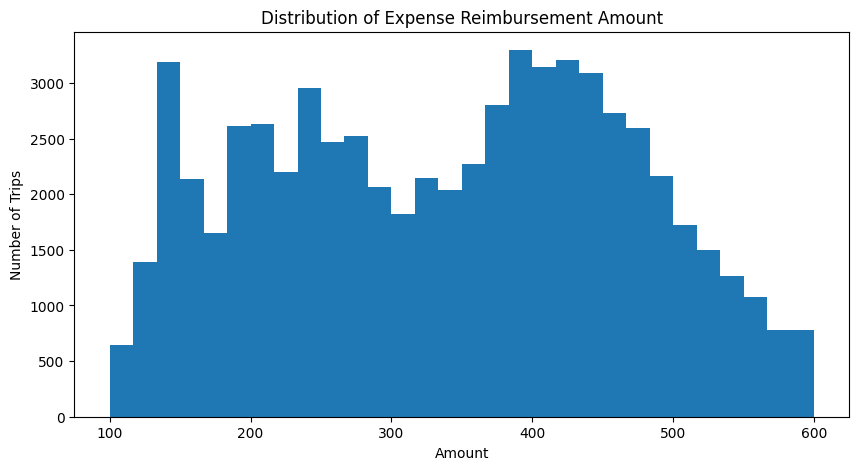

In [119]:
plt.figure(figsize=(10,5))

plt.hist(event_attr["ExpenseReimbursementAmount"].dropna(), bins=30)

plt.title("Distribution of Expense Reimbursement Amount")
plt.xlabel("Amount")
plt.ylabel("Number of Trips")

plt.show()

In [120]:
event_attr["ReasonForDelay"].value_counts()

,count
ReasonForDelay,
Weather delay,1700
Mechanical issue,1575
Airport congestion,1478
Security screening,1439
Traffic congestion,196
Rental desk queue,149
Vehicle breakdown,149
Technical difficulty,46
System downtime,44


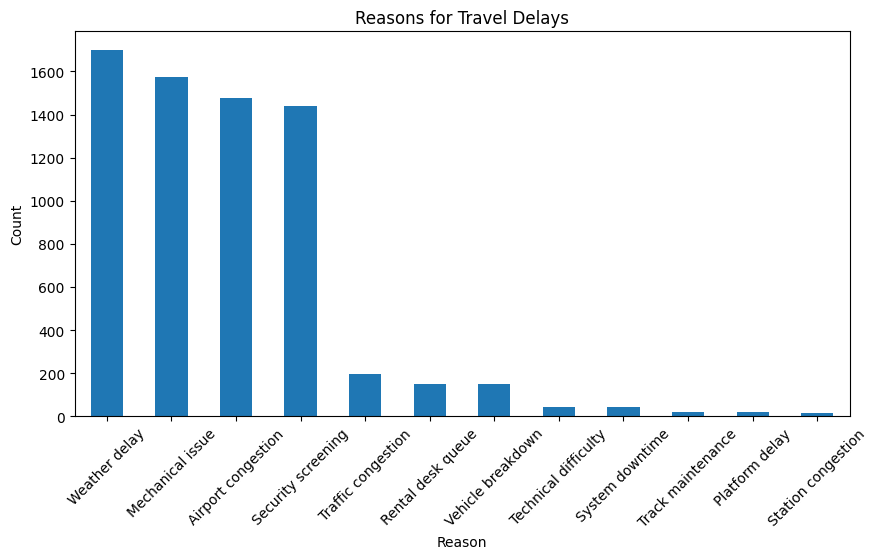

In [121]:
plt.figure(figsize=(10,5))

event_attr["ReasonForDelay"].value_counts().plot(kind="bar")

plt.title("Reasons for Travel Delays")
plt.xlabel("Reason")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

In [122]:
event_attr["ReasonForTransportationChange"].value_counts()

,count
ReasonForTransportationChange,
Cost optimization,1905
Client preference,1889
Time constraints,1867
Safety concern,1861


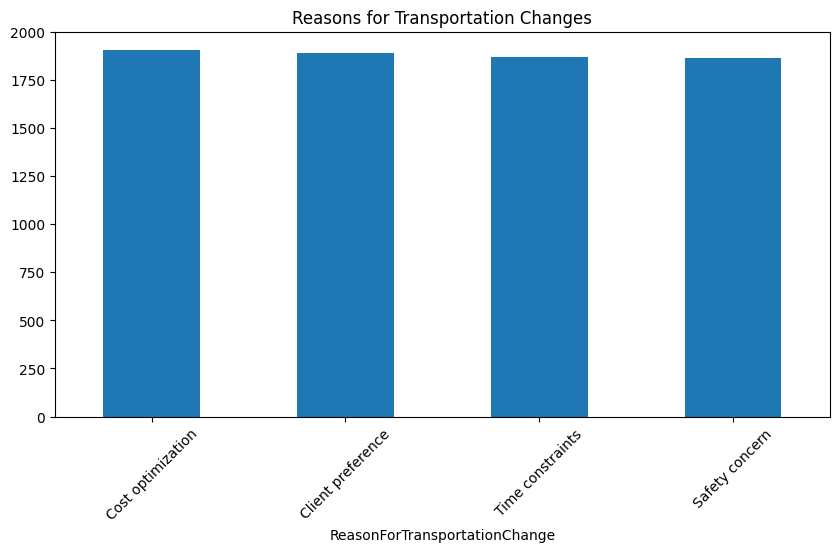

In [123]:
plt.figure(figsize=(10,5))

event_attr["ReasonForTransportationChange"].value_counts().plot(kind="bar")

plt.title("Reasons for Transportation Changes")

plt.xticks(rotation=45)

plt.show()

In [124]:
event_attr["ProcessCode"].value_counts().head(10)

,count
ProcessCode,
V1,34625
V18,2060
V17,2027
V20,1911
V16,1910
V19,1902
V21,1857
V15,1812
V14,1607


In [125]:
print(y.shape)

(65289,)


In [126]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [127]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(52231, 12)
(13058, 12)
(52231,)
(13058,)


In [128]:
for var in list(globals().keys()):
    if "train" in var.lower() or "encoded" in var.lower():
        print(var)

train_test_split
train
X_train
y_train


In [129]:
print(list(globals().keys()))

['__name__', '__doc__', '__package__', '__loader__', '__spec__', '__builtin__', '__builtins__', '_ih', '_oh', '_dh', 'In', 'Out', 'get_ipython', 'exit', 'quit', '_', '__', '___', '_i', '_ii', '_iii', '_i1', 'pd', 'np', 'plt', 'sns', 'train_test_split', 'LabelEncoder', 'accuracy_score', 'classification_report', 'roc_auc_score', 'RandomForestClassifier', 'warnings', '_i2', 'train', 'test', '_i3', '_3', '_i4', '_i5', '_5', '_i6', '_i7', '_7', '_i8', '_i9', '_9', '_i10', '_10', '_i11', 'features', 'X', 'y', 'X_test', '_i12', 'label_encoders', 'categorical_cols', 'col', 'le', 'combined', '_i13', '_13', '_i14', 'X_train', 'X_valid', 'y_train', 'y_valid', '_i15', '_i16', 'model', '_16', '_i17', 'pred', '_i18', 'accuracy', '_i19', 'pred_prob', 'roc', '_i20', 'test_prob', '_i21', 'submission', '_21', '_i22', '_i23', '_i24', '_24', '_i25', 'feature_importance', '_25', '_i26', '_i27', '_i28', '_i29', '_i30', 'event_log', '_30', '_i31', '_i32', '_32', '_i33', '_33', '_i34', '_34', '_i35', '_35', '

In [130]:
!pip install xgboost

In [131]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, roc_auc_score

xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_valid)
y_prob_xgb = xgb.predict_proba(X_valid)[:, 1]

print("Accuracy:", accuracy_score(y_valid, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_valid, y_prob_xgb))

Accuracy: 0.9932608362689539
ROC-AUC: 0.9993407485954668


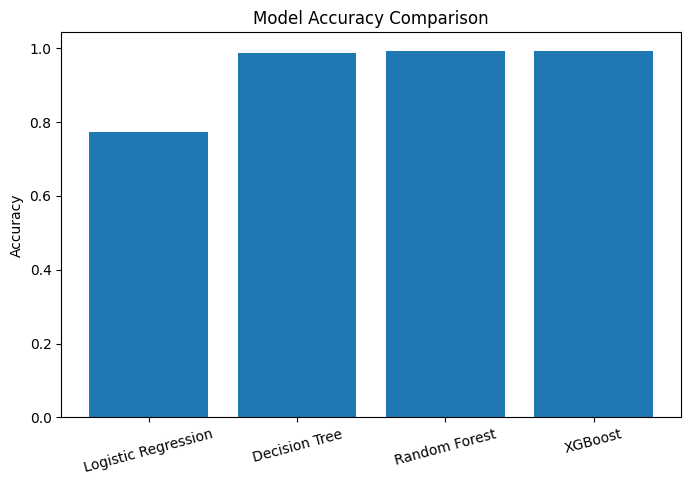

In [132]:
import pandas as pd
import matplotlib.pyplot as plt

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        0.7722,
        0.9873,
        0.9917,
        0.9933
    ]
})

plt.figure(figsize=(8,5))

plt.bar(results["Model"], results["Accuracy"])

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=15)

plt.show()

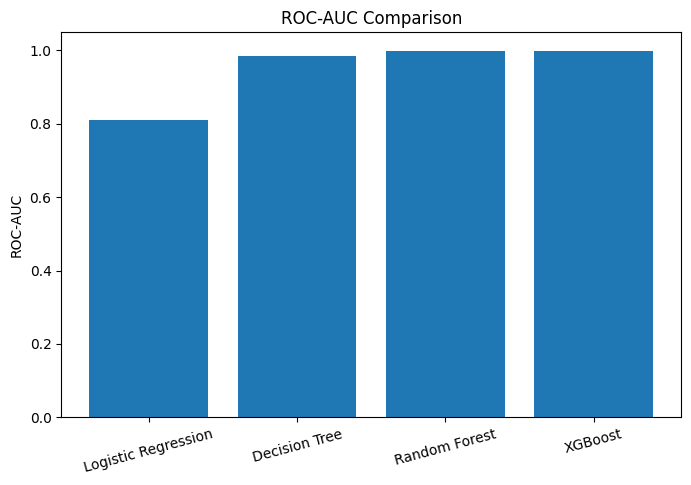

In [133]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "ROC_AUC": [
        0.8102,
        0.9844,
        0.9979,
        0.9993
    ]
})

plt.figure(figsize=(8,5))

plt.bar(results["Model"], results["ROC_AUC"])

plt.title("ROC-AUC Comparison")
plt.ylabel("ROC-AUC")
plt.xticks(rotation=15)

plt.show()

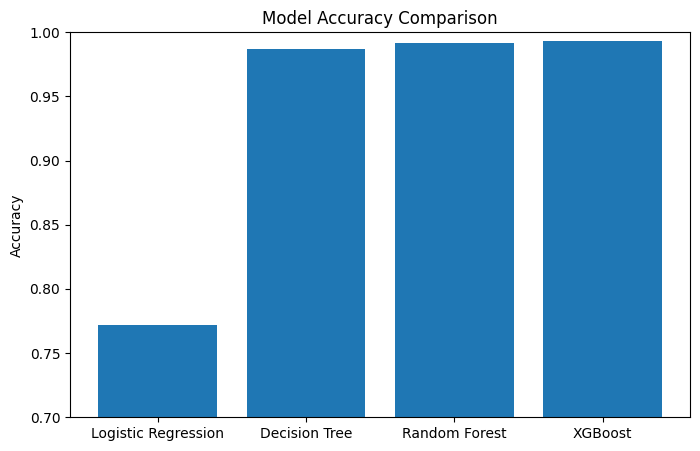

In [134]:
import pandas as pd
import matplotlib.pyplot as plt

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        0.7722,
        0.9873,
        0.9917,
        0.9933
    ]
})

plt.figure(figsize=(8,5))
plt.bar(results["Model"], results["Accuracy"])

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0.7,1.0)

plt.show()

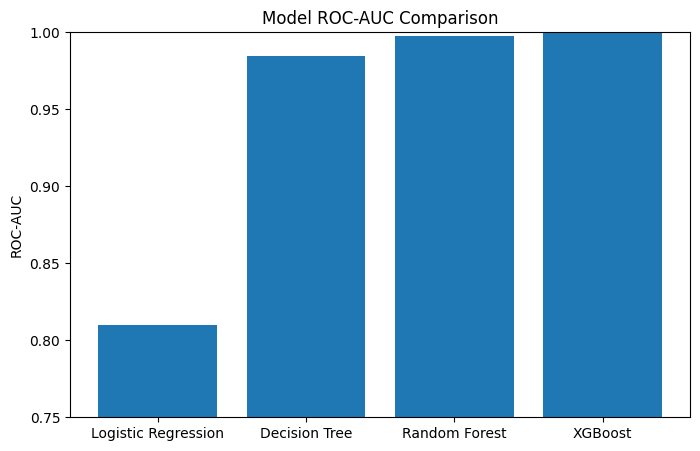

In [135]:
results = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "ROC_AUC":[
        0.8102,
        0.9844,
        0.9979,
        0.9993
    ]
})

plt.figure(figsize=(8,5))

plt.bar(results["Model"], results["ROC_AUC"])

plt.title("Model ROC-AUC Comparison")
plt.ylabel("ROC-AUC")
plt.ylim(0.75,1.0)

plt.show()

In [136]:
feature_importance.head(10)

,Feature,Importance
2,ArrivalLocationCountry,0.240231
3,ArrivalLocationCity,0.210938
0,DepartureLocationCountry,0.135272
4,ShippingType,0.128378
5,ShippingTypeDescription,0.122260
1,DepartureLocationCity,0.081266
10,HotelNights,0.033270
7,OutOfPolicy,0.015701
11,NetCosts,0.014175
9,BusinessUnit,0.008282


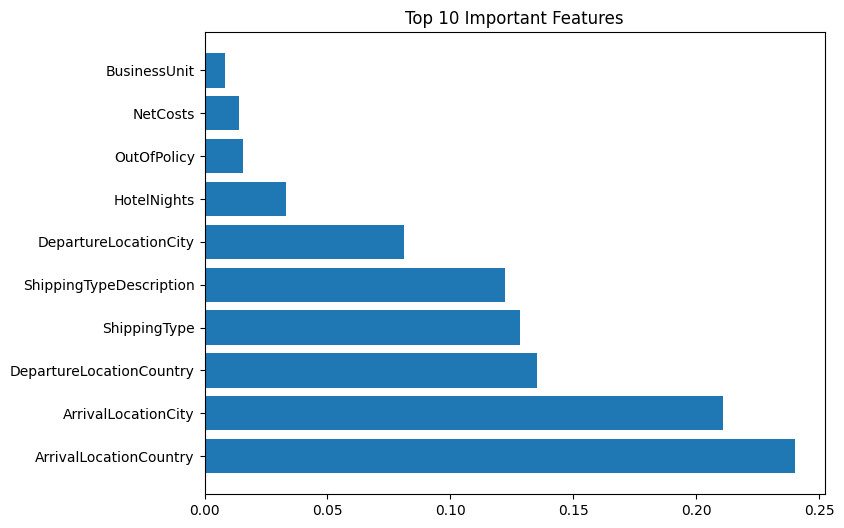

In [137]:
plt.figure(figsize=(8,6))

plt.barh(
    feature_importance["Feature"][:10],
    feature_importance["Importance"][:10]
)

plt.title("Top 10 Important Features")

plt.show()

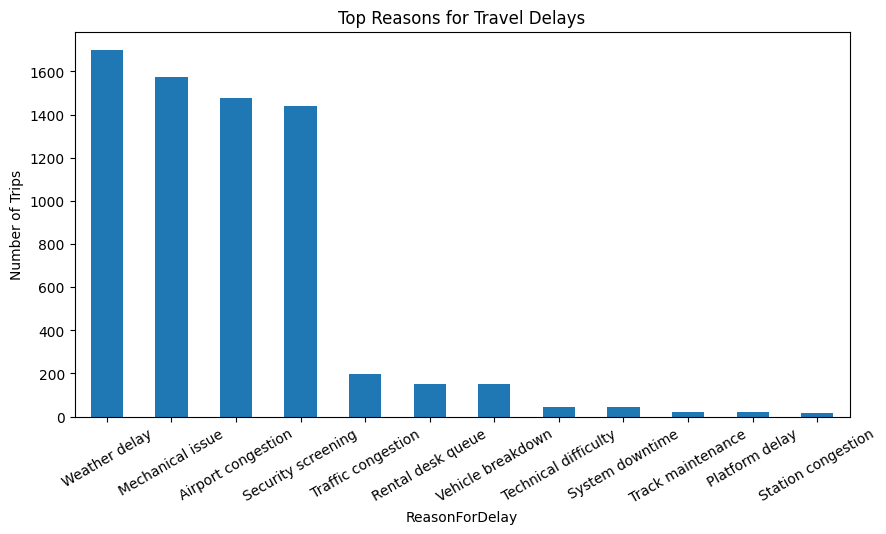

In [138]:
plt.figure(figsize=(10,5))

event_attr["ReasonForDelay"].value_counts().plot(kind="bar")

plt.title("Top Reasons for Travel Delays")

plt.ylabel("Number of Trips")

plt.xticks(rotation=30)

plt.show()

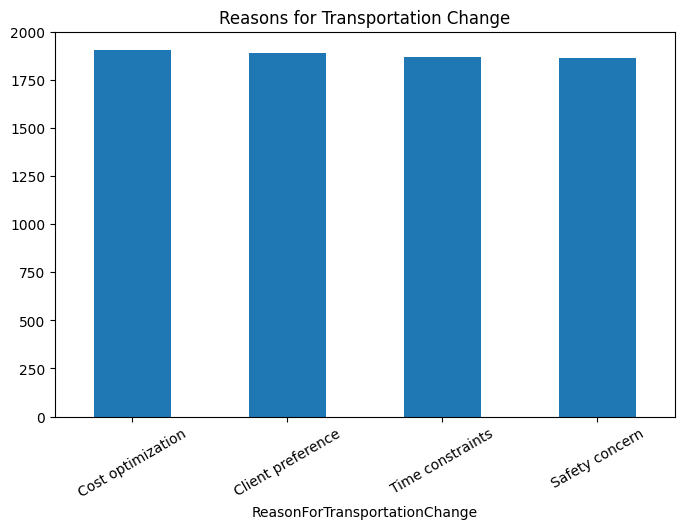

In [139]:
plt.figure(figsize=(8,5))

event_attr["ReasonForTransportationChange"].value_counts().plot(kind="bar")

plt.title("Reasons for Transportation Change")

plt.xticks(rotation=30)

plt.show()

In [140]:
import joblib

In [141]:
joblib.dump(xgb, "xgboost_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [142]:
import os

print(os.listdir())

['.config', 'xgboost_model.pkl', 'public_trip_event_attributes.csv', 'private_trip_data.csv', 'sample_submission.csv', 'private_trip_event_attributes.csv', 'submission.csv', 'private_trip_event_log.csv', 'Sustainability Data Dictionary.xlsx', 'public_trip_event_log.csv', 'public_trip_data.csv', 'sample_data']


In [143]:
print(X_valid.shape)
print(X_test.shape)
print(test.shape)

(13058, 12)
(13058, 12)
(21764, 13)


In [144]:
print(features)

['DepartureLocationCountry', 'DepartureLocationCity', 'ArrivalLocationCountry', 'ArrivalLocationCity', 'ShippingType', 'ShippingTypeDescription', 'Purpose', 'OutOfPolicy', 'EntitiyCode', 'BusinessUnit', 'HotelNights', 'NetCosts']


In [147]:
X_test_submission = test[features].copy()

print(X_test_submission.shape)

(21764, 12)


In [148]:
categorical_cols = [
    'DepartureLocationCountry',
    'DepartureLocationCity',
    'ArrivalLocationCountry',
    'ArrivalLocationCity',
    'ShippingTypeDescription',
    'Purpose',
    'OutOfPolicy',
    'BusinessUnit'
]

for col in categorical_cols:
    X_test_submission[col] = label_encoders[col].transform(X_test_submission[col])

In [149]:
final_predictions = xgb.predict(X_test_submission)

print(len(final_predictions))

21764


In [150]:
submission = pd.DataFrame({
    "TripID": test["TripID"],
    "HighCarbon": final_predictions
})

submission.to_csv("submission_xgboost.csv", index=False)

submission.head()

,TripID,HighCarbon
0,2,1
1,4,0
2,5,1
3,14,0
4,15,0


In [151]:
X_test_submission = test[features].copy()

print(X_test_submission.shape)

(21764, 12)


In [152]:
print(type(xgb))

<class 'xgboost.sklearn.XGBClassifier'>


In [153]:
print(train.shape)
print(test.shape)
print(features)

(65289, 20)
(21764, 13)
['DepartureLocationCountry', 'DepartureLocationCity', 'ArrivalLocationCountry', 'ArrivalLocationCity', 'ShippingType', 'ShippingTypeDescription', 'Purpose', 'OutOfPolicy', 'EntitiyCode', 'BusinessUnit', 'HotelNights', 'NetCosts']


In [154]:
print(X_train.shape)
print(X_valid.shape)
print(y_train.shape)
print(y_valid.shape)

(52231, 12)
(13058, 12)
(52231,)
(13058,)


In [155]:
print(type(label_encoders))

<class 'dict'>


In [156]:
print(train.shape)
print(test.shape)

(65289, 20)
(21764, 13)


In [157]:
print(X_train.shape)
print(X_valid.shape)
print(y_train.shape)
print(y_valid.shape)

(52231, 12)
(13058, 12)
(52231,)
(13058,)


In [158]:
print(type(label_encoders))

<class 'dict'>


In [159]:
from xgboost import XGBClassifier

In [160]:
!pip install xgboost

In [161]:
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [162]:
from sklearn.metrics import accuracy_score, roc_auc_score

y_pred = xgb.predict(X_valid)
y_prob = xgb.predict_proba(X_valid)[:,1]

print("Accuracy:", accuracy_score(y_valid, y_pred))
print("ROC-AUC:", roc_auc_score(y_valid, y_prob))

Accuracy: 0.9934905804870577
ROC-AUC: 0.9993703975508961


In [163]:
X_test_submission = test[features].copy()

In [164]:
categorical_cols = [
    'DepartureLocationCountry',
    'DepartureLocationCity',
    'ArrivalLocationCountry',
    'ArrivalLocationCity',
    'ShippingTypeDescription',
    'Purpose',
    'OutOfPolicy',
    'BusinessUnit'
]

for col in categorical_cols:
    X_test_submission[col] = label_encoders[col].transform(X_test_submission[col])

In [165]:
final_predictions = xgb.predict(X_test_submission)

print(len(final_predictions))

21764


In [166]:
submission = pd.DataFrame({
    "TripID": test["TripID"],
    "HighCarbon": final_predictions
})

submission.to_csv("submission_xgboost.csv", index=False)

submission.head()

,TripID,HighCarbon
0,2,1
1,4,0
2,5,1
3,14,0
4,15,0


In [167]:
X_test_submission = test[features].copy()

print(X_test_submission.shape)

(21764, 12)


In [168]:
categorical_cols = [
    'DepartureLocationCountry',
    'DepartureLocationCity',
    'ArrivalLocationCountry',
    'ArrivalLocationCity',
    'ShippingTypeDescription',
    'Purpose',
    'OutOfPolicy',
    'BusinessUnit'
]

for col in categorical_cols:
    X_test_submission[col] = label_encoders[col].transform(
        X_test_submission[col]
    )

print("Encoding Completed!")

Encoding Completed!


In [169]:
final_predictions = xgb.predict(X_test_submission)

print(len(final_predictions))

21764


In [170]:
submission = pd.DataFrame({
    "TripID": test["TripID"],
    "HighCarbon": final_predictions
})

submission.to_csv("submission_xgboost.csv", index=False)

submission.head()

,TripID,HighCarbon
0,2,1
1,4,0
2,5,1
3,14,0
4,15,0


In [171]:
print(submission.shape)

(21764, 2)


In [172]:
submission.to_csv("submission_xgboost.csv", index=False)